In [60]:
from ase.io import read
import numpy as np
frames = read('./char_curves.xyz', ':')
for frame in frames:
    frame.info['energy'] = frame.get_potential_energy()
    # frame.arrays['forces'] = frame.get_forces()
energies = [frame.info["energy"] for frame in frames]
energies = np.asarray(energies).reshape(-1, 1)
energies.shape

(25000, 1)

In [61]:

import anisoap
from anisoap.representations import EllipsoidalDensityProjection
import numpy as np
from matplotlib import pyplot as plt
from ase.io import read, write
from ase import Atoms
from tqdm.auto import tqdm

In [62]:
import metatensor
from metatensor import operations

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LinearRegression, LassoCV
from skmatter.preprocessing import StandardFlexibleScaler
from scipy.spatial.transform import Rotation
# from rascal.representations import SphericalInvariants

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

def rmse(*x):
    return np.sqrt(mse(*x))

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/var/folders/wj/7rfv11952g53zf6ztk8k8g980000gn/T/ipykernel_81322/1027566381.py:7: SyntaxWarning: invalid escape sequence '\e'
  axs[0].set_ylabel("Energy/$\epsilon$")
/var/folders/wj/7rfv11952g53zf6ztk8k8g980000gn/T/ipykernel_81322/1027566381.py:10: SyntaxWarning: invalid escape sequence '\e'
  axs[1].set_xlabel("Energy/$\epsilon$")


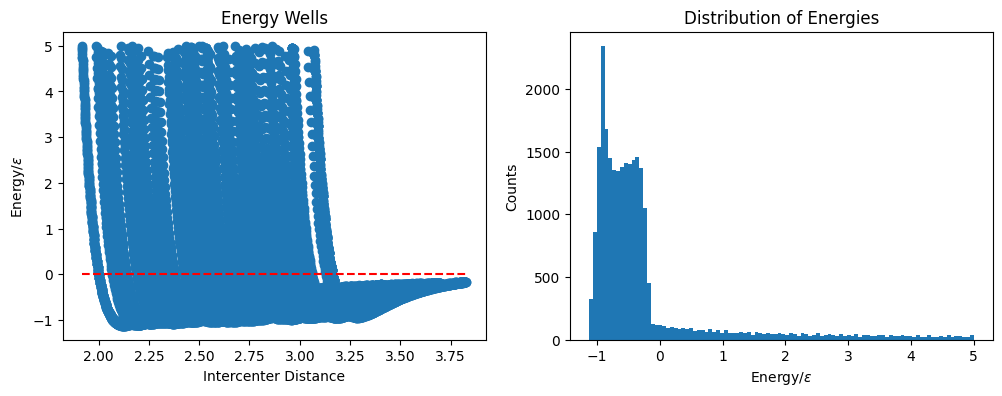

<Figure size 640x480 with 0 Axes>

In [73]:
distances = [frame.info["d"] for frame in frames]
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), squeeze=True, layout=None)
axs[0].scatter(distances, energies)
axs[0].plot([min(distances), max(distances)], [0, 0], 'r--')
axs[0].set_title("Energy Wells")
axs[0].set_xlabel("Intercenter Distance")
axs[0].set_ylabel("Energy/$\epsilon$")
axs[1].hist(energies, bins=100)
axs[1].set_title("Distribution of Energies")
axs[1].set_xlabel("Energy/$\epsilon$")
axs[1].set_ylabel("Counts")
plt.show()

plt.savefig('wells.png')

In [64]:
lmax = 10
nmax = 10
cutoff_radius = 10.
rgw = 2.0
rcond = 1E-6

In [65]:
calculator = EllipsoidalDensityProjection(max_angular=lmax,
                                              max_radial=nmax,
                                              radial_basis_name='gto',
                                              rotation_type="quaternion",
                                              rotation_key="quaternions",
                                              cutoff_radius=cutoff_radius,
                                              radial_gaussian_width=rgw,
                                              basis_rcond=rcond,
                                              basis_tol=1e-2
                                             )
power_spectrum = calculator.power_spectrum(frames)

In [66]:
power_spectrum_cleaned = power_spectrum[:, power_spectrum.var(axis=0)>=1E-12]
x_scaler = StandardFlexibleScaler(column_wise=False).fit(power_spectrum_cleaned)
x = x_scaler.transform(power_spectrum_cleaned)

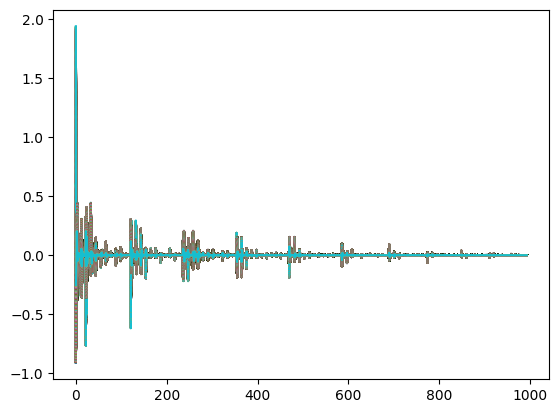

<Figure size 640x480 with 0 Axes>

In [72]:
plt.plot(x.T)
plt.show()
plt.savefig('signal.png')

In [70]:
y_scaler = StandardFlexibleScaler(column_wise=True).fit(energies)
y = y_scaler.transform(energies)
i_train, i_test = train_test_split(np.arange(y.shape[0]), test_size=0.1, random_state=2)
lr = RidgeCV(cv=5, alphas=np.logspace(-5, 0, 20), fit_intercept=False)
# lr = LinearRegression()
# lr = LassoCV(cv=5, alphas=np.logspace(-5, -2, 1), fit_intercept=False, max_iter=10000)
lr.fit(x[i_train], y[i_train])
energies_pred = y_scaler.inverse_transform(lr.predict(x).reshape(-1,1))
energies_r2_train = lr.score(x[i_train], y[i_train])
energies_r2_test = lr.score(x[i_test], y[i_test])
energies_rmse_train = rmse(energies_pred[i_train], energies[i_train])
energies_rmse_test = rmse(energies_pred[i_test], energies[i_test])
print(f"{energies_r2_train=:.3f}\n{energies_r2_test=:.3f}\n{energies_rmse_train=:.3f}\n{energies_rmse_test=:.3f}")
print(f"{lr.alpha_=}")

energies_r2_train=0.933
energies_r2_test=0.939
energies_rmse_train=0.284
energies_rmse_test=0.285
lr.alpha_=np.float64(1e-05)


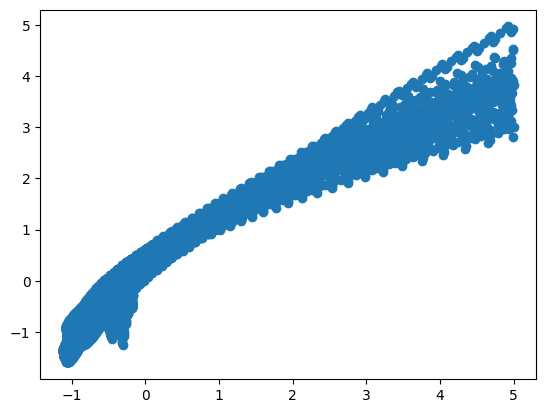

In [74]:
plt.scatter(energies, energies_pred)
plt.savefig('parity.png')

In [75]:
!open .